In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [61]:
df = pd.read_csv("../datasets_pc/Titanic-Dataset.csv")
df.shape
# df.head()

(891, 12)

In [62]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [63]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

print("Categorical Columns: ", cat_cols)
print("Numeric Columns: ", num_cols)

Categorical Columns:  ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numeric Columns:  ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [64]:
df[cat_cols].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [65]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [66]:
(df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
dtype: float64

In [67]:
df = df.drop(columns=['Cabin'])
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.dropna(subset=['Embarked'], inplace=True)

In [68]:
df.shape

(889, 11)

<Axes: xlabel='Age'>

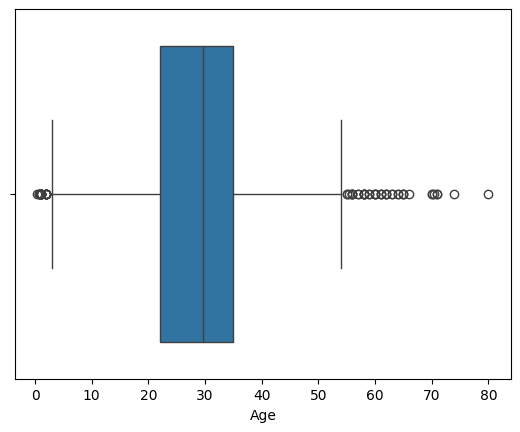

In [69]:
sns.boxplot(x=df['Age'])

In [71]:
mean = df['Age'].mean()
std = df['Age'].std()

upper_limit = mean + 2 * std
lower_limit = mean - 2 * std

df = df[(df['Age']>=lower_limit) & (df['Age']<=upper_limit)]

In [74]:
scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0.000000,0.0,1.0,"Braund, Mr. Owen Harris",male,0.349515,0.125,0.0,A/5 21171,0.014151,S
1,0.001124,1.0,0.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.660194,0.125,0.0,PC 17599,0.139136,C
2,0.002247,1.0,1.0,"Heikkinen, Miss. Laina",female,0.427184,0.000,0.0,STON/O2. 3101282,0.015469,S
3,0.003371,1.0,0.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.601942,0.125,0.0,113803,0.103644,S
4,0.004494,0.0,1.0,"Allen, Mr. William Henry",male,0.601942,0.000,0.0,373450,0.015713,S
